# Data Project: Inequality in Denmark

Group: Kristian, Kasper, David og Bjørn

This project looks at how income inequality in Denmark has developed over time, using two tables from Statistics Denmark (IFOR41 and IFOR32). Both are based on equivalised disposable income (income after tax and transfers, adjusted for household size). The project has two parts: an empirical analysis of real data (section 1) and a simulation of the income distribution (section 2).

## Setup

We install and import the packages we need, plus our own module `opgave1.py`, which holds the functions for downloading and cleaning data from Statistics Denmark.

In [1]:
# install dstapi (run once, then comment out)
#%pip install git+https://github.com/alemartinello/dstapi

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
import opgave1
import opgave2

# 1. Inequality in Denmark

## 1.1 The Gini coefficient and the top-10% share

We use two measures of income inequality for Denmark over time:

- The Gini coefficient from table IFOR41, where the inequality measure is picked with `ULLIG = 70`. Gini runs from 0 (everyone equal) to 100 (one person has all the income).
- The top-10% share, calculated from the decile groups in table IFOR32.

All downloading and cleaning is done through the `load_dst` function in `opgave1.py`, so getting a new table only takes one function call.

### Gini coefficient (IFOR41)

We get the Gini for all of Denmark (`KOMMUNEDK = 000`) for every year.

In [3]:
gini_dk = opgave1.load_dst(
    'IFOR41',
    variables=[
        {'code': 'ULLIG',     'values': ['70']},   # Gini coefficient
        {'code': 'KOMMUNEDK', 'values': ['000']},  # all of Denmark
        {'code': 'Tid',       'values': ['*']},     # all years
    ],
    value_name='gini',
)
gini_dk.head()

,gini
year,
1987,22.07
1988,22.06
1989,21.93
1990,22.16
1991,21.99


### Top-10% share (IFOR32)

IFOR32 gives the average income in each of the ten decile groups. Since each decile holds the same number of people, the top decile's share of total income is:

$$\text{top 10 pct.} = \frac{\bar{y}_{10}}{\sum_{d=1}^{10}\bar{y}_d}$$

We first get all ten deciles for Denmark.

In [4]:
deciles_dk = opgave1.load_dst(
    'IFOR32',
    variables=[
        {'code': 'DECILGEN',  'values': ['*']},    # all 10 deciles
        {'code': 'KOMMUNEDK', 'values': ['000']},  # all of Denmark
        {'code': 'Tid',       'values': ['*']},     # all years
    ],
    value_name='avg_income',
)
deciles_dk.head(12)

,DECILGEN,avg_income
year,,
1987,Third decil,68786
1987,Fourth decil,77577
1987,Fifth decil,85361
1987,Sixth decil,92777
1987,Seventh decil,100691
1987,Eigth decil,110184
1987,Ninth decil,123582
1987,Tenth decil,169598
1987,Second decil,59014


Then we calculate the top-10% share by dividing the tenth decile's income by the sum of all ten deciles, for each year.

In [5]:
# denominator: total income per year (sum over all 10 deciles)
total_per_year = deciles_dk.groupby('year')['avg_income'].sum()

# numerator: the tenth decile's income per year
top_decile = deciles_dk[deciles_dk['DECILGEN'] == 'Tenth decil']['avg_income']

# top-10% share = tenth decile / sum of all deciles
top10 = pd.DataFrame({'top10': top_decile / total_per_year})
top10.head()

,top10
year,
1987,0.184549
1988,0.184289
1989,0.184952
1990,0.186415
1991,0.186683


### Combining the two measures

We merge the two series on year. `validate='1:1'` checks that there is exactly one row per year in each series - if not, pandas raises an error instead of silently duplicating rows.

In [6]:
df_dk = pd.merge(
    gini_dk,          # column 'gini'
    top10,            # column 'top10'
    left_index=True,  # match on the year index in both
    right_index=True,
    validate='1:1',   # check: exactly one row per year in each
)
df_dk.head()

,gini,top10
year,,
1987,22.07,0.184549
1988,22.06,0.184289
1989,21.93,0.184952
1990,22.16,0.186415
1991,21.99,0.186683


### Figure: development over time

The two measures are on very different scales (Gini around 22-30, the share around 0.18-0.25), so we plot them on separate y-axes.

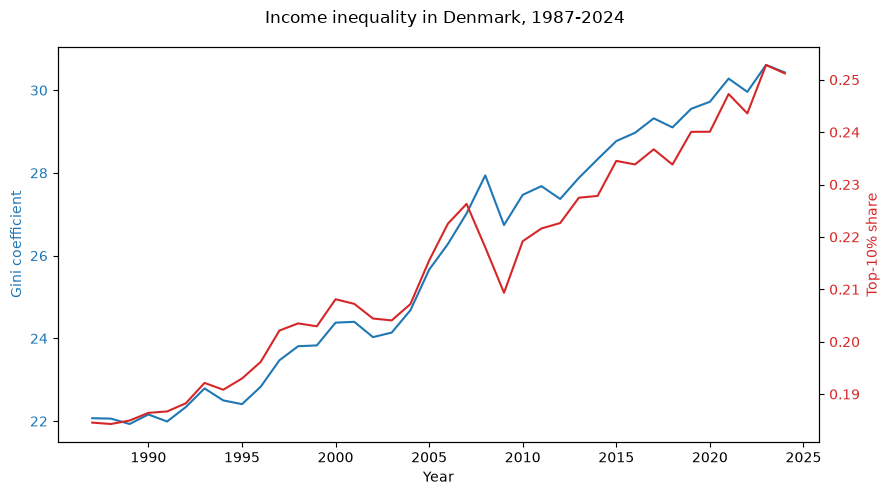

In [7]:
fig, ax1 = plt.subplots(figsize=(9, 5))

# left axis: Gini
color1 = 'tab:blue'
ax1.plot(df_dk.index, df_dk['gini'], color=color1, label='Gini coefficient')
ax1.set_xlabel('Year')
ax1.set_ylabel('Gini coefficient', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# right axis: top-10% share
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.plot(df_dk.index, df_dk['top10'], color=color2, label='Top-10% share')
ax2.set_ylabel('Top-10% share', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle('Income inequality in Denmark, 1987-2024')
fig.tight_layout()
plt.show()

### Correlation and interpretation

We calculate the Pearson correlation between the two measures to see if they tell the same story.

In [8]:
corr = df_dk['gini'].corr(df_dk['top10'])
print(f'Correlation between Gini and top-10% share: {corr:.3f}')

Correlation between Gini and top-10% share: 0.982


Interpretation: Both measures show a clear and steady rise in income inequality in Denmark since 1987. The Gini coefficient has gone from about 22 to about 30, and the top-10% share from about 0.185 to about 0.25 - so the richest 10% take a growing slice of total income. The two series track each other closely across the whole period, which shows up as a very high correlation (close to 1). The fact that two separately built measures move almost identically makes us more confident that this is a real change in inequality, and not just a quirk of one particular measure.

## 1.2 Prediction

We fit a linear and a quadratic trend to the Gini coefficient and use them to predict inequality in 2030 and 2040. We solve the least-squares problem ourselves with `scipy.optimize.minimize`, and check it against `np.polyfit`.

### Preparing the data

We center the years around their mean. Without centering, $t^2$ would be very large numbers (e.g. $1987^2 \approx 3.9$ million), which makes the optimization numerically messy. Centering doesn't change the shape of the curve, only how we read the constant term.

In [9]:
years = df_dk.index.values.astype(float)
gini_vals = df_dk['gini'].values

# center the years so the numbers are small and numerically stable
t = years - years.mean()

print("Number of points:", len(t))
print("t ranges from", t.min(), "to", t.max())

Number of points: 38
t ranges from -18.5 to 18.5


### Linear trend

We write the objective function ourselves (the sum of squared residuals) and minimize it. As a check, we solve the same problem analytically with `np.polyfit`; the two should give almost identical coefficients.

In [10]:
# objective function: sum of squared residuals (SSR)
def ssr_linear(beta, t, y):
    b0, b1 = beta
    prediction = b0 + b1 * t
    residuals = y - prediction
    return np.sum(residuals**2)

# minimize SSR with scipy
result_lin = optimize.minimize(
    ssr_linear,
    x0=[0, 0],           # starting guess for [b0, b1]
    args=(t, gini_vals), # extra arguments passed to ssr_linear
)
b0_lin, b1_lin = result_lin.x
print(f"Linear trend (minimize):  b0 = {b0_lin:.4f},  b1 = {b1_lin:.4f}")

# check with np.polyfit (returns [b1, b0])
poly_lin = np.polyfit(t, gini_vals, deg=1)
print(f"Linear trend (polyfit):   b0 = {poly_lin[1]:.4f},  b1 = {poly_lin[0]:.4f}")

Linear trend (minimize):  b0 = 25.9184,  b1 = 0.2635
Linear trend (polyfit):   b0 = 25.9184,  b1 = 0.2635


### Quadratic trend

Same approach, but with an extra term $\beta_2 t^2$ that can capture whether the rise speeds up or flattens out.

In [11]:
def ssr_quad(beta, t, y):
    b0, b1, b2 = beta
    prediction = b0 + b1 * t + b2 * t**2
    residuals = y - prediction
    return np.sum(residuals**2)

result_quad = optimize.minimize(
    ssr_quad,
    x0=[0, 0, 0],
    args=(t, gini_vals),
)
b0_q, b1_q, b2_q = result_quad.x
print(f"Quadratic trend (minimize):  b0 = {b0_q:.4f},  b1 = {b1_q:.4f},  b2 = {b2_q:.4f}")

# check with np.polyfit (returns [b2, b1, b0])
poly_q = np.polyfit(t, gini_vals, deg=2)
print(f"Quadratic trend (polyfit):   b0 = {poly_q[2]:.4f},  b1 = {poly_q[1]:.4f},  b2 = {poly_q[0]:.4f}")

Quadratic trend (minimize):  b0 = 25.7768,  b1 = 0.2635,  b2 = 0.0012
Quadratic trend (polyfit):   b0 = 25.7768,  b1 = 0.2635,  b2 = 0.0012


### Predictions for 2030 and 2040

Important: since the models are fitted on centered years, future years have to be centered with the same mean before we plug them into the model.

In [12]:
year_mean = years.mean()
future_years = np.array([2030, 2040])
t_future = future_years - year_mean

pred_lin = b0_lin + b1_lin * t_future
pred_quad = b0_q + b1_q * t_future + b2_q * t_future**2

for yr, pl, pq in zip(future_years, pred_lin, pred_quad):
    print(f"{yr}:  linear = {pl:.2f},  quadratic = {pq:.2f}")

2030:  linear = 32.38,  quadratic = 32.94
2040:  linear = 35.01,  quadratic = 36.27


### Figure: data, trends and predictions

The dashed line marks where the actual data ends (2024). Everything to the right is extrapolation.

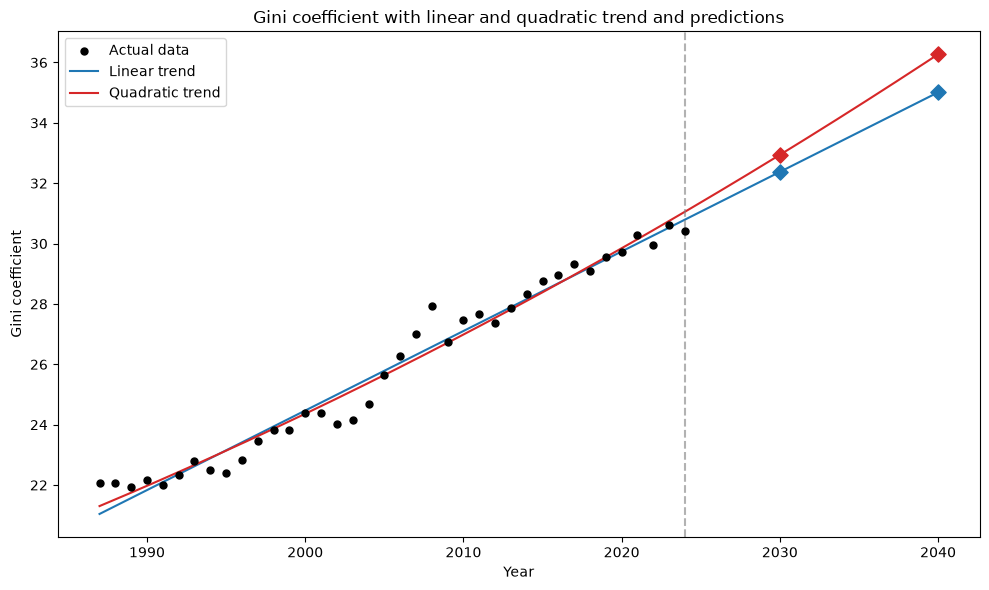

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

# actual data
ax.scatter(years, gini_vals, color='black', s=25, label='Actual data', zorder=3)

# smooth grid for drawing the trends
year_grid = np.linspace(1987, 2040, 200)
t_grid = year_grid - year_mean

ax.plot(year_grid, b0_lin + b1_lin * t_grid,
        color='tab:blue', label='Linear trend')
ax.plot(year_grid, b0_q + b1_q * t_grid + b2_q * t_grid**2,
        color='tab:red', label='Quadratic trend')

# mark the predictions
ax.scatter(future_years, pred_lin, color='tab:blue', marker='D', s=60, zorder=4)
ax.scatter(future_years, pred_quad, color='tab:red', marker='D', s=60, zorder=4)

# vertical line where data ends
ax.axvline(years.max(), color='gray', linestyle='--', alpha=0.6)

ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')
ax.set_title('Gini coefficient with linear and quadratic trend and predictions')
ax.legend()
fig.tight_layout()
plt.show()

Interpretation: The Gini coefficient has risen steadily from about 22 in 1987 to about 30 in 2024, a clear increase in income inequality. The linear trend fits the data well, with a slope of about 0.26 Gini points per year. The quadratic trend only adds a tiny curvature term ($b_2 \approx 0.001$), so inside the data range the two models are almost the same. The difference only shows up in the predictions: the linear model predicts a Gini of 32.4 in 2030 and 35.0 in 2040, while the quadratic predicts 32.9 and 36.3. The quadratic is higher because the small positive curvature makes inequality speed up a bit. The gap between the models grows the further out we extrapolate, which is a reminder that predictions far beyond the data depend heavily on the model choice and should be read with caution.

## 1.3 Municipalities

We repeat the analysis at the municipality level by getting all municipalities (`KOMMUNEDK = *`), and look at the most/least unequal ones as well as the biggest/smallest changes in Gini over time.

Note: Gini for small municipalities can jump around a lot from year to year, so we always plot the underlying series before reading anything into the rankings.

### Get Gini for all municipalities

The only change from 1.1 is `KOMMUNEDK` from `['000']` to `['*']`. Since the geography variable now varies, `load_dst` automatically keeps the `KOMMUNEDK` column.

In [14]:
gini_kom = opgave1.load_dst(
    'IFOR41',
    variables=[
        {'code': 'ULLIG',     'values': ['70']},   # Gini
        {'code': 'KOMMUNEDK', 'values': ['*']},     # ALL geographies
        {'code': 'Tid',       'values': ['*']},     # all years
    ],
    value_name='gini',
)
print("Shape:", gini_kom.shape)
gini_kom.head()

Shape: (3762, 2)


,KOMMUNEDK,gini
year,,
1987,Læsø,22.81
1987,Vesthimmerlands,21.75
1987,Frederikshavn,20.35
1987,Brønderslev,21.51
1987,Viborg,20.69


### Reshape to wide format

We use `pivot` to get years as rows and municipalities as columns. That makes per-municipality statistics (like the mean) a simple column operation.

In [15]:
gini_wide = gini_kom.pivot(columns='KOMMUNEDK', values='gini')
print("Shape:", gini_wide.shape)   # (number of years, number of geographies)
gini_wide.iloc[:5, :5]

Shape: (38, 99)


KOMMUNEDK,Aabenraa,Aalborg,Aarhus,Albertslund,All Denmark
year,,,,,
1987,21.33,21.01,22.10,18.82,22.07
1988,21.51,21.61,22.62,18.95,22.06
1989,20.74,21.22,22.59,20.43,21.93
1990,20.83,21.10,23.10,19.99,22.16
1991,20.86,21.15,23.47,20.40,21.99


### Most and least unequal municipalities

We rank municipalities by their average Gini over the whole period (more robust than a single year). "All Denmark" is dropped since it isn't a municipality.

In [16]:
# drop "All Denmark" - it isn't a municipality
kommuner = gini_wide.drop(columns='All Denmark')

# average Gini per municipality over the whole period
mean_gini = kommuner.mean().sort_values(ascending=False)

print("=== 10 MOST unequal municipalities (avg Gini) ===")
print(mean_gini.head(10))
print("\n=== 10 LEAST unequal municipalities (avg Gini) ===")
print(mean_gini.tail(10))

=== 10 MOST unequal municipalities (avg Gini) ===
KOMMUNEDK
Gentofte          39.860789
Rudersdal         37.331579
Hørsholm          35.603947
Lyngby-Taarbæk    31.543421
Frederiksberg     30.732632
Copenhagen        28.646316
Aarhus            28.447895
Fredensborg       27.922368
Furesø            26.773421
Helsingør         26.513421
dtype: float64

=== 10 LEAST unequal municipalities (avg Gini) ===
KOMMUNEDK
Assens             22.032368
Bornholm           22.006842
Faaborg-Midtfyn    21.996316
Nyborg             21.980263
Nordfyns           21.978947
Vallensbæk         21.603421
Favrskov           21.444737
Tårnby             21.157895
Halsnæs            21.120263
Egedal             20.672105
dtype: float64


### Plot: most and least unequal municipalities

We show the ten most and ten least unequal municipalities in a horizontal bar chart, with the two groups in different colours so the contrast is easy to see.

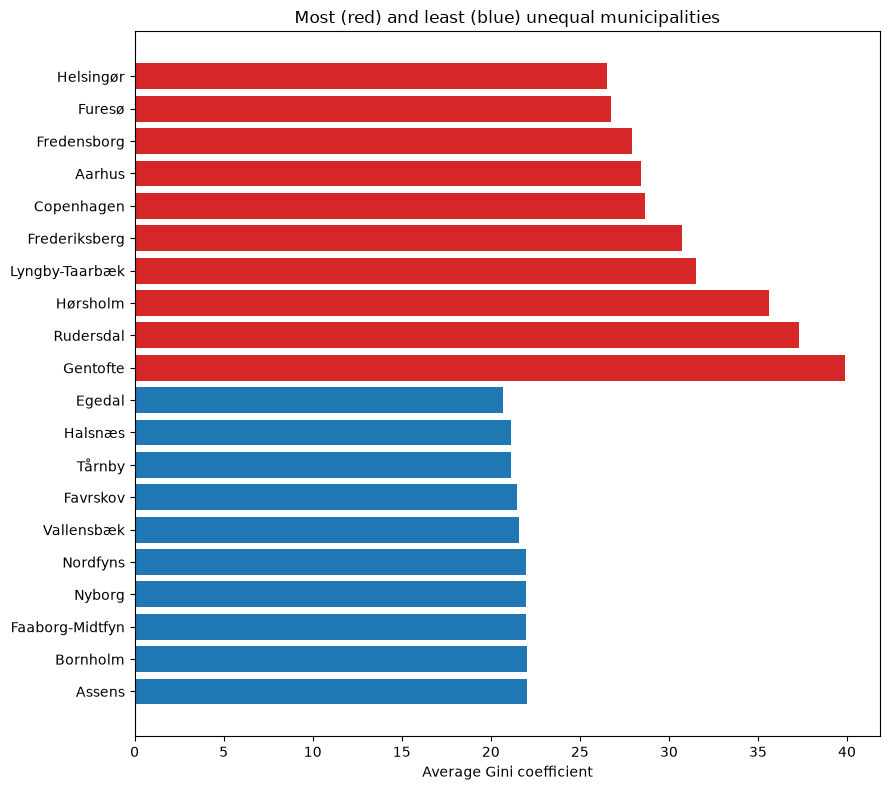

In [17]:
# take the 10 most and 10 least unequal municipalities
top10_kom = mean_gini.head(10)
bottom10_kom = mean_gini.tail(10)

# put them together for one chart (least at the bottom, most at the top)
plot_data = pd.concat([bottom10_kom, top10_kom])

# colours: red for the most unequal, blue for the least unequal
colors = ['tab:blue'] * len(bottom10_kom) + ['tab:red'] * len(top10_kom)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(plot_data.index, plot_data.values, color=colors)
ax.set_xlabel('Average Gini coefficient')
ax.set_title('Most (red) and least (blue) unequal municipalities')
fig.tight_layout()
plt.show()

### Biggest change in inequality over time

We measure the change as Gini in the last year minus Gini in the first year, for each municipality.

In [18]:
first_year = kommuner.index.min()   # 1987
last_year = kommuner.index.max()    # 2024

change = (kommuner.loc[last_year] - kommuner.loc[first_year]).sort_values(ascending=False)

print(f"Change in Gini from {first_year} to {last_year}\n")
print("=== 10 BIGGEST increases ===")
print(change.head(10))
print("\n=== 10 BIGGEST decreases / smallest increases ===")
print(change.tail(10))

Change in Gini from 1987 to 2024

=== 10 BIGGEST increases ===
KOMMUNEDK
Vejen             25.12
Rudersdal         18.26
Gentofte          17.94
Lyngby-Taarbæk    14.31
Copenhagen        11.92
Hørsholm          11.68
Fredensborg       11.59
Aarhus            11.33
Frederiksberg     11.26
Vallensbæk        10.80
dtype: float64

=== 10 BIGGEST decreases / smallest increases ===
KOMMUNEDK
Odder              3.77
Mariagerfjord      3.67
Stevns             3.42
Sorø               2.92
Faaborg-Midtfyn    2.89
Bornholm           2.72
Læsø               2.60
Faxe               2.45
Ærø                2.35
Fanø               0.67
dtype: float64


### Checking the underlying series

Before reading anything into the ranking of changes, we plot the series for the municipalities with the biggest "increase" together with the national average. This shows whether a large measured change is a real, lasting trend or just a data break / noise in the endpoints.

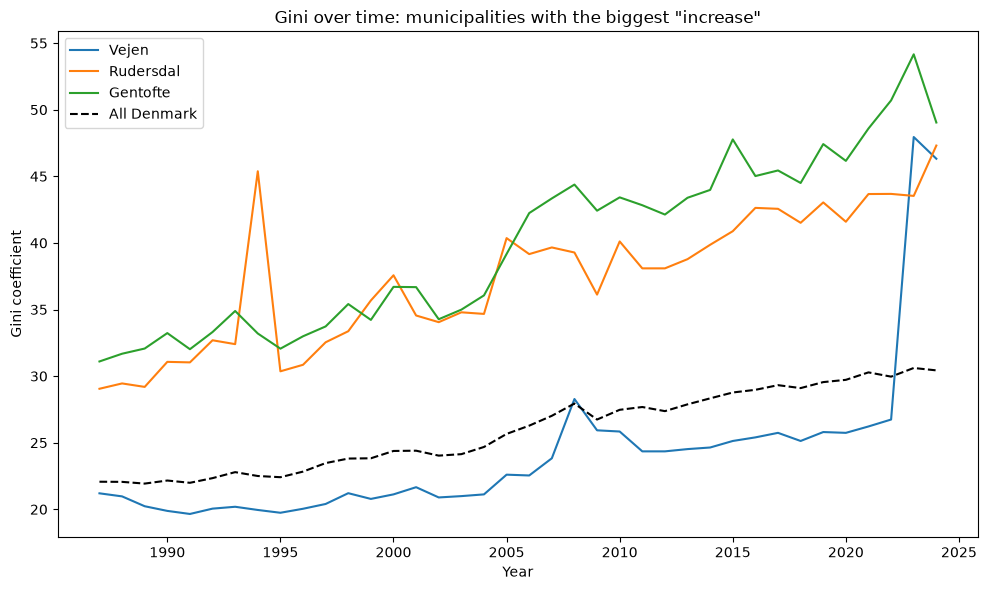

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

for kom in ['Vejen', 'Rudersdal', 'Gentofte']:
    ax.plot(kommuner.index, kommuner[kom], label=kom)

# national average as reference
ax.plot(gini_wide.index, gini_wide['All Denmark'],
        color='black', linestyle='--', label='All Denmark')

ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')
ax.set_title('Gini over time: municipalities with the biggest "increase"')
ax.legend()
fig.tight_layout()
plt.show()

Interpretation: At the municipality level, inequality varies much more than at the national level. The most unequal municipalities are consistently the wealthy ones north of Copenhagen - Gentofte (avg Gini ~40), Rudersdal and Hørsholm - where high top incomes create a wide spread. The least unequal are more homogeneous suburban and provincial municipalities like Egedal and Halsnæs (~21).

When we rank by the change in Gini from 1987 to 2024, Vejen tops the list with +25 points. But the figure shows this comes from a sudden jump in 2022-2023 rather than a lasting trend - most likely a data break. The other big increases (Rudersdal, Gentofte, Copenhagen) are gradual and believable, and stay well above the national average.

This is the point the assignment warns about: rankings based on two endpoints are sensitive to noise and data breaks in exactly those two years, so you should always look at the underlying series before drawing conclusions. A more robust measure of the trend would be the slope from a trend fitted to the whole period (as in section 1.2).

## 1.4 Extension: income level and inequality

As an extension we look at whether there is a link between a municipality's income level and its inequality: are richer municipalities also more unequal? We use IFOR32, which we already know, to work out each municipality's average income, and relate it to the average Gini from section 1.3.

### Get decile incomes for all municipalities

Same call as the IFOR32 one in 1.1, but with `KOMMUNEDK = *`.

In [20]:
deciles_kom = opgave1.load_dst(
    'IFOR32',
    variables=[
        {'code': 'DECILGEN',  'values': ['*']},    # all 10 deciles
        {'code': 'KOMMUNEDK', 'values': ['*']},     # ALL municipalities
        {'code': 'Tid',       'values': ['*']},     # all years
    ],
    value_name='avg_income',
)
print("Shape:", deciles_kom.shape)
deciles_kom.head()

Shape: (37620, 3)


,DECILGEN,KOMMUNEDK,avg_income
year,,,
1987,Sixth decil,Vesthimmerlands,83991
1987,Fifth decil,Vesthimmerlands,77185
1987,Fourth decil,Vesthimmerlands,69840
1987,Third decil,Vesthimmerlands,62376
1987,Second decil,Vesthimmerlands,54003


### Average income per municipality, joined with Gini

Since each decile group holds the same number of people, the mean of the ten deciles equals the municipality's average income. We also average over all years to get one robust number per municipality, and join it with `mean_gini` from 1.3.

In [21]:
# average income per municipality (mean over deciles AND years)
income_per_kom = deciles_kom.groupby('KOMMUNEDK')['avg_income'].mean()

# put both measures in one table, one row per municipality
kom_summary = pd.DataFrame({
    'mean_income': income_per_kom,
    'mean_gini': mean_gini,        # from 1.3
})
kom_summary = kom_summary.drop(index='All Denmark', errors='ignore')

print("Number of municipalities:", len(kom_summary))
kom_summary.head()

Number of municipalities: 98


,mean_income,mean_gini
KOMMUNEDK,,
Aabenraa,187563.623684,24.010000
Aalborg,188040.044737,24.951579
Aarhus,196023.142105,28.447895
Albertslund,183031.478947,23.252368
Allerød,258965.031579,23.574474


### Scatter plot and correlation

Each municipality is one point. We label a few well-known ones so the plot is readable.

Correlation (income vs. Gini): 0.749


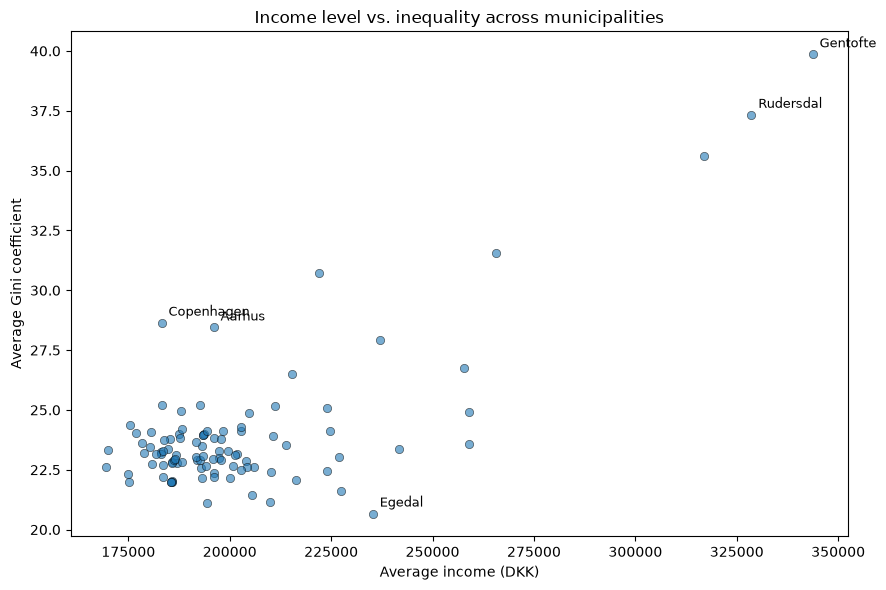

In [22]:
corr_kom = kom_summary['mean_income'].corr(kom_summary['mean_gini'])
print(f"Correlation (income vs. Gini): {corr_kom:.3f}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(kom_summary['mean_income'], kom_summary['mean_gini'],
           alpha=0.6, edgecolor='k', linewidth=0.5)

for name in ['Gentofte', 'Rudersdal', 'Aarhus', 'Copenhagen', 'Egedal']:
    if name in kom_summary.index:
        x = kom_summary.loc[name, 'mean_income']
        y = kom_summary.loc[name, 'mean_gini']
        ax.annotate(name, (x, y), fontsize=9,
                    xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Average income (DKK)')
ax.set_ylabel('Average Gini coefficient')
ax.set_title('Income level vs. inequality across municipalities')
fig.tight_layout()
plt.show()

Interpretation: There is a clear positive link between a municipality's income level and its inequality (correlation ≈ 0.75): richer municipalities tend to be more unequal. The link is largely driven by the wealthy municipalities north of Copenhagen (Gentofte, Rudersdal, Hørsholm), which have both the highest incomes and the highest inequality. The reason is their income mix: people with very high capital and top incomes living alongside ordinary wage earners and pensioners. It's that spread - not the wealth itself - that pushes the Gini up.

The link isn't deterministic, though: Egedal has a high income level but low inequality, because incomes there are evenly spread. It's also worth noting that the correlation depends heavily on the few outliers in the top right; without them the link among the remaining municipalities would be much weaker. So the result should be read as a tendency, not a rule.

# 2. Simulating the income distribution

In this part we simulate a life-cycle model of income for 50,000 individuals and study the resulting income distribution. The model is built in `opgave2.py`, which the notebook imports and calls. All imports are already done at the top of the notebook.

## 2.1 Simulating an income distribution

We run the baseline model. It returns education, ages, employment state, human capital and income for every individual across the life cycle.

In [23]:
# run the baseline model
education, ages, state, human_capital, income = opgave2.simulate_model()

print("Number of individuals:", income.shape[0])
print("Number of ages:", income.shape[1])

Number of individuals: 50000
Number of ages: 48


## 2.2 Checking and describing the simulation

Before using the simulated data we check that it behaves as the model says it should. The education shares should match the input probabilities `p_e`, and the unemployment rate should settle at sigma / (sigma + lambda).

In [24]:
# education shares should match p_e
education_shares = np.bincount(education) / opgave2.N
print("Education shares:", education_shares)
print("Input probabilities p_e:", opgave2.p_e)

# unemployment rate should match the theoretical value
unemployment_by_age = np.mean(state == 1, axis=0)
theoretical_unemp = opgave2.sigma / (opgave2.sigma + opgave2.lambda_)
print("\nAverage unemployment rate:", unemployment_by_age.mean().round(3))
print("Theoretical unemployment rate:", round(theoretical_unemp, 3))

Education shares: [0.40006 0.35142 0.24852]
Input probabilities p_e: [0.4, 0.35, 0.25]

Average unemployment rate: 0.102
Theoretical unemployment rate: 0.077


The education shares match `p_e` and the unemployment rate is close to the theoretical value, so the simulation works as intended.

### Income over the life cycle

We plot mean income and a set of percentiles across age. This shows both how income grows over the life cycle and how the spread widens.

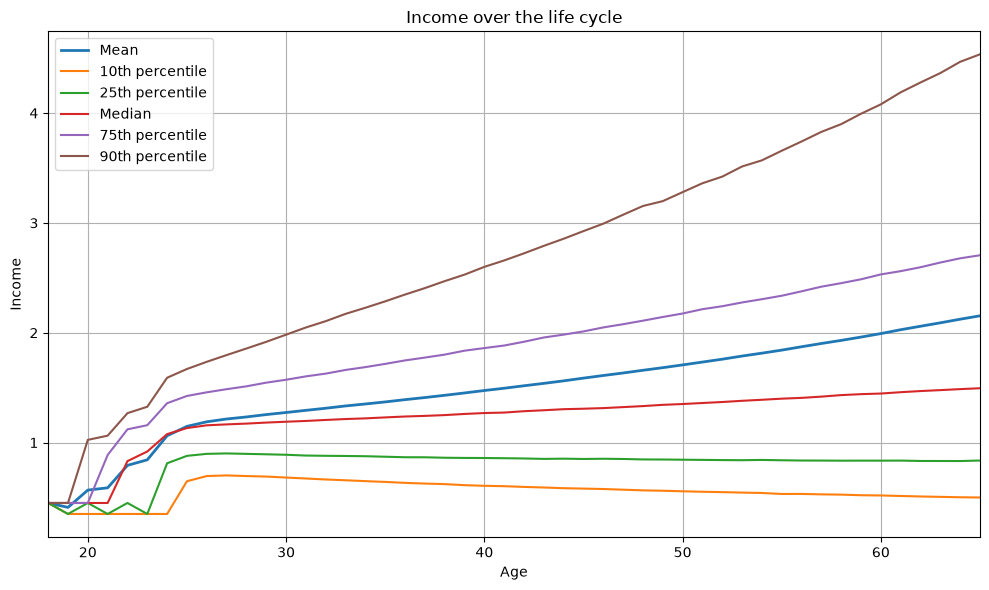

In [25]:
mean_income = np.mean(income, axis=0)

p10 = np.percentile(income, 10, axis=0)
p25 = np.percentile(income, 25, axis=0)
p50 = np.percentile(income, 50, axis=0)
p75 = np.percentile(income, 75, axis=0)
p90 = np.percentile(income, 90, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(ages, mean_income, label="Mean", linewidth=2)
plt.plot(ages, p10, label="10th percentile")
plt.plot(ages, p25, label="25th percentile")
plt.plot(ages, p50, label="Median")
plt.plot(ages, p75, label="75th percentile")
plt.plot(ages, p90, label="90th percentile")
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Income over the life cycle")
plt.legend()
plt.grid(True)
plt.xlim(18, 65)
plt.tight_layout()
plt.show()

Income rises steeply early in the life cycle as people finish education and build human capital, then flattens. The gap between the top and bottom percentiles widens with age, so inequality grows over the life cycle.

### Income distribution at different ages

We plot histograms of income at ages 25, 35, 45 and 60. We cut the x-axis at the 99th percentile so the bulk of the distribution is easy to read and a few very high incomes do not stretch the axis.

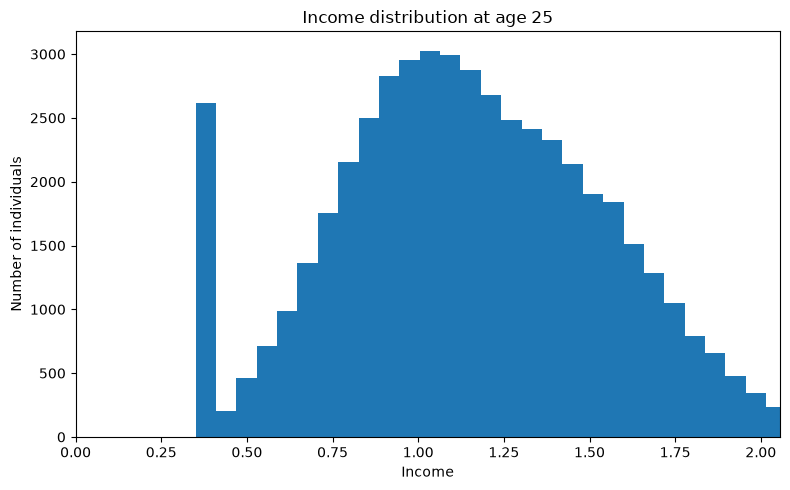

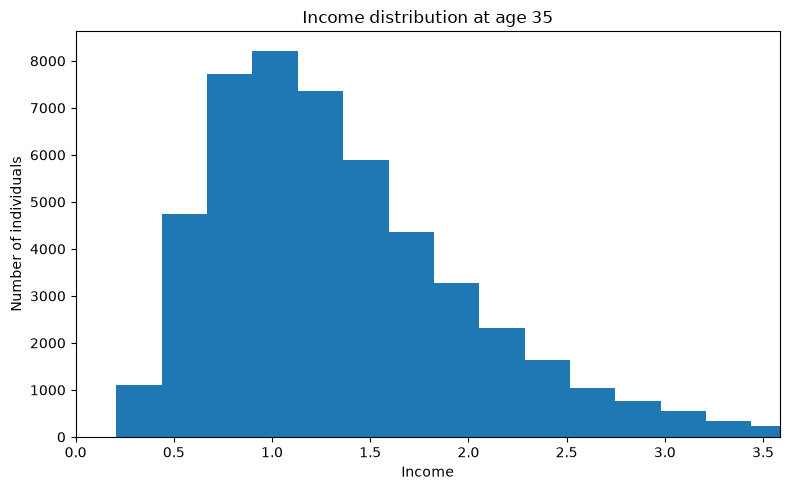

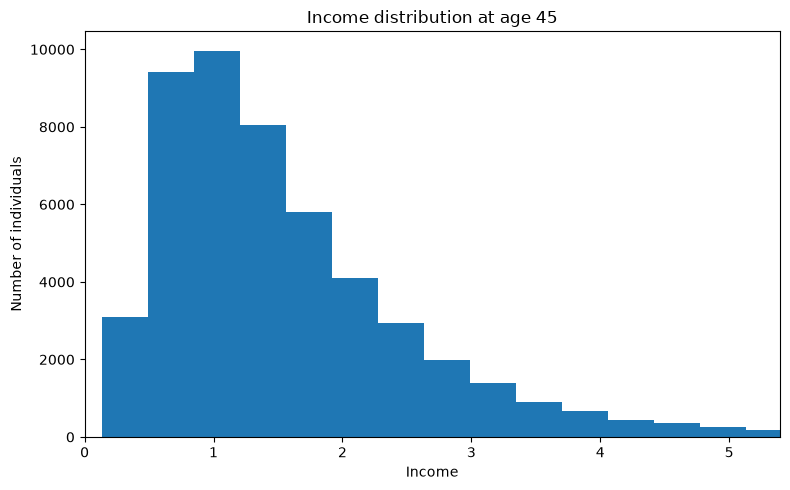

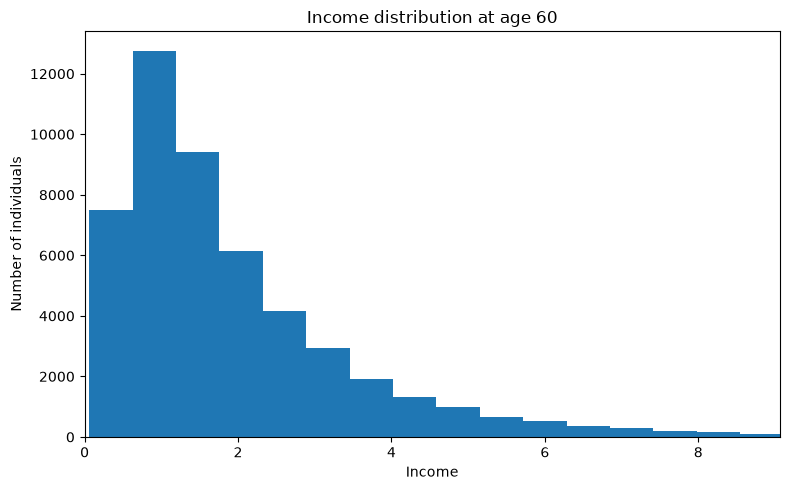

In [26]:
for age in [25, 35, 45, 60]:
    age_index = np.where(ages == age)[0][0]
    income_at_age = income[:, age_index]

    plt.figure(figsize=(8, 5))
    plt.hist(income_at_age, bins=40)
    plt.xlabel("Income")
    plt.ylabel("Number of individuals")
    plt.title(f"Income distribution at age {age}")

    # cut the x-axis at the 99th percentile so the shape is clearer
    plt.xlim(0, np.percentile(income_at_age, 99))
    plt.tight_layout()
    plt.show()

The distributions are right-skewed at every age, and the skew grows with age: a long tail of high incomes builds up as human capital and shocks accumulate over the life cycle.

## 2.3 Computing the Gini coefficient

We write our own Gini function and test it on two distributions where the answer is known, before using it on the simulated data.

In [27]:
def gini(x):
    # sort incomes from lowest to highest
    x = np.sort(x)
    n = len(x)
    # standard formula for the Gini coefficient
    gini_value = (2 * np.sum((np.arange(1, n + 1)) * x) / (n * np.sum(x)) - (n + 1) / n)
    return gini_value

### Testing the Gini function

First a uniform distribution on [0, 1], where the theoretical Gini is 1/3.

In [28]:
uniform_income = np.linspace(0, 1, 10000)
gini_uniform = gini(uniform_income)

print("Gini for uniform distribution:", round(gini_uniform, 4))
print("Theoretical value (1/3):", round(1/3, 4))

Gini for uniform distribution: 0.3334
Theoretical value (1/3): 0.3333


Then a lognormal distribution. For a lognormal with parameter s, the theoretical Gini is 2 * Phi(s / sqrt(2)) - 1.

In [29]:
from scipy.stats import norm

s = 0.5
rng_test = np.random.default_rng(123)
lognormal_income = rng_test.lognormal(0, s, 10000)
gini_lognormal = gini(lognormal_income)

theoretical_lognormal = 2 * norm.cdf(s / np.sqrt(2)) - 1
print("Gini for lognormal distribution:", round(gini_lognormal, 4))
print("Theoretical value:", round(theoretical_lognormal, 4))

Gini for lognormal distribution: 0.2742
Theoretical value: 0.2763


Both tests match the theoretical values closely, so the Gini function works correctly.

### Gini for the full sample and by age

We compute the Gini for all income observations pooled together, and also for each age separately. We define a small helper `gini_by_age` so we can reuse it later when comparing scenarios.

In [30]:
def gini_by_age(income_matrix):
    """Return an array with the Gini coefficient at each age."""
    return np.array([gini(income_matrix[:, j]) for j in range(income_matrix.shape[1])])

# pooled Gini (all individuals and ages together)
gini_pooled = gini(income.flatten())
print("Pooled Gini coefficient:", round(gini_pooled, 3))

# Gini by age for the baseline model
gini_age_baseline = gini_by_age(income)

Pooled Gini coefficient: 0.377


### Lorenz curve

The Lorenz curve shows the cumulative share of income held by the cumulative share of the population. The further it bows away from the diagonal, the more unequal the distribution.

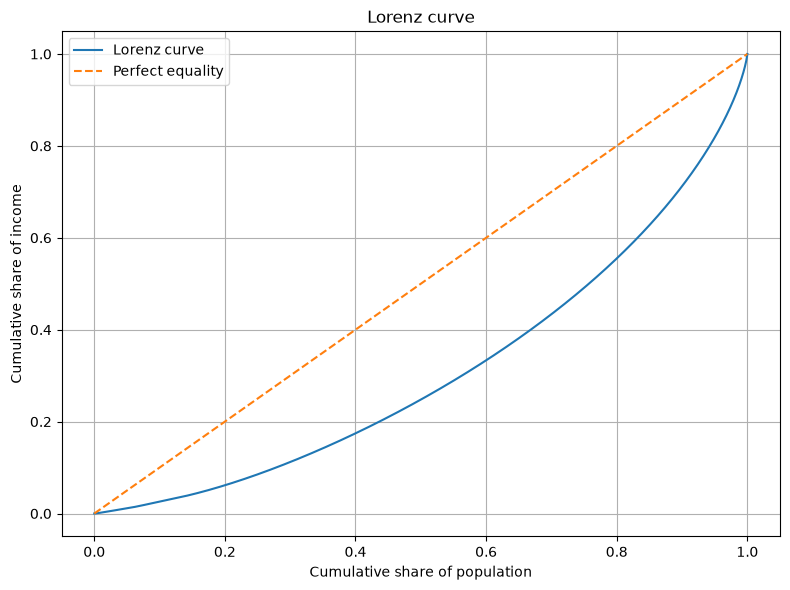

In [31]:
sorted_income = np.sort(income.flatten())
cumulative_income = np.cumsum(sorted_income) / sorted_income.sum()
cumulative_population = np.arange(1, len(sorted_income) + 1) / len(sorted_income)

plt.figure(figsize=(8, 6))
plt.plot(cumulative_population, cumulative_income, label="Lorenz curve")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect equality")
plt.xlabel("Cumulative share of population")
plt.ylabel("Cumulative share of income")
plt.title("Lorenz curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Gini by age

We plot the Gini coefficient at each age. This separates within-age inequality from the life-cycle income growth we saw earlier.

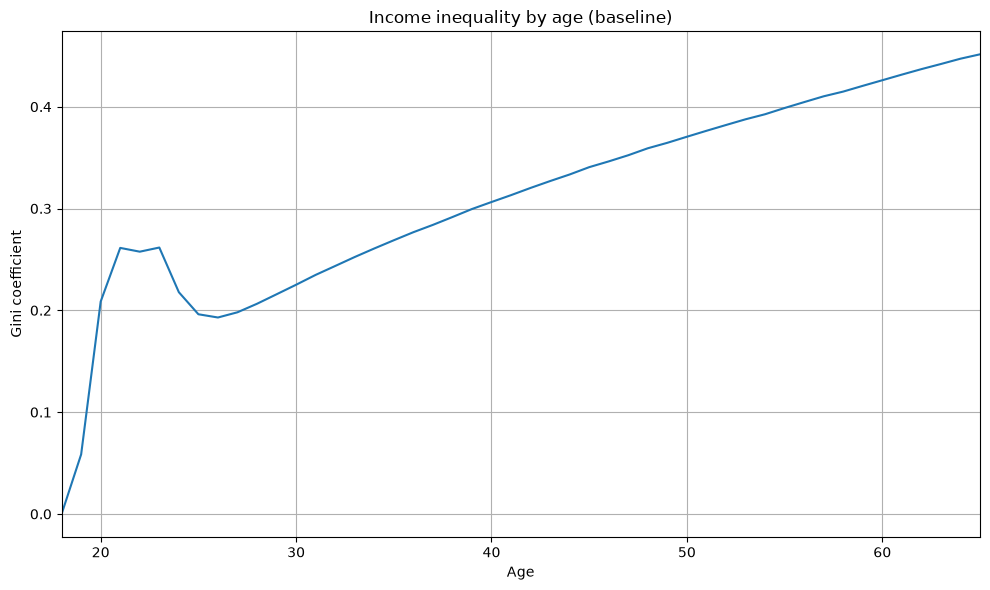

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(ages, gini_age_baseline)
plt.xlabel("Age")
plt.ylabel("Gini coefficient")
plt.title("Income inequality by age (baseline)")
plt.xlim(18, 65)
plt.grid(True)
plt.tight_layout()
plt.show()

The pooled Gini is higher than the Gini at most single ages. That is because the pooled measure mixes together people at different points in the life cycle, so it captures both within-age inequality and the fact that older people generally earn more than younger people.

## 2.4 What drives inequality?

We turn off one mechanism at a time (education differences, human capital shocks, depreciation, unemployment) and see how the Gini changes compared with the baseline. We collect all the results in one table and one plot instead of printing them one by one.

In [33]:
# run all scenarios once and store the income matrices
importlib_ok = True
import importlib
importlib.reload(opgave2)

scenarios = {
    'Baseline':          income,
    'No education':      opgave2.simulate_no_education()[4],
    'No shocks':         opgave2.simulate_no_shocks()[4],
    'No depreciation':   opgave2.simulate_no_depreciation()[4],
    'No unemployment':   opgave2.simulate_no_unemployment()[4],
}

# note: [4] picks the income matrix out of the returned tuple

### Results table

For each scenario we report the pooled Gini and the Gini at age 45 (a representative within-age value).

In [34]:
age45_index = np.where(ages == 45)[0][0]

rows = []
for name, inc in scenarios.items():
    rows.append({
        'Scenario': name,
        'Pooled Gini': round(gini(inc.flatten()), 3),
        'Gini at age 45': round(gini(inc[:, age45_index]), 3),
    })

results_24 = pd.DataFrame(rows).set_index('Scenario')
results_24

,Pooled Gini,Gini at age 45
Scenario,,
Baseline,0.377,0.341
No education,0.298,0.298
No shocks,0.280,0.215
No depreciation,0.384,0.329
No unemployment,0.387,0.325


### Gini by age: each scenario versus baseline

We plot the Gini at each age for every scenario, so we can see where each mechanism matters most across the life cycle.

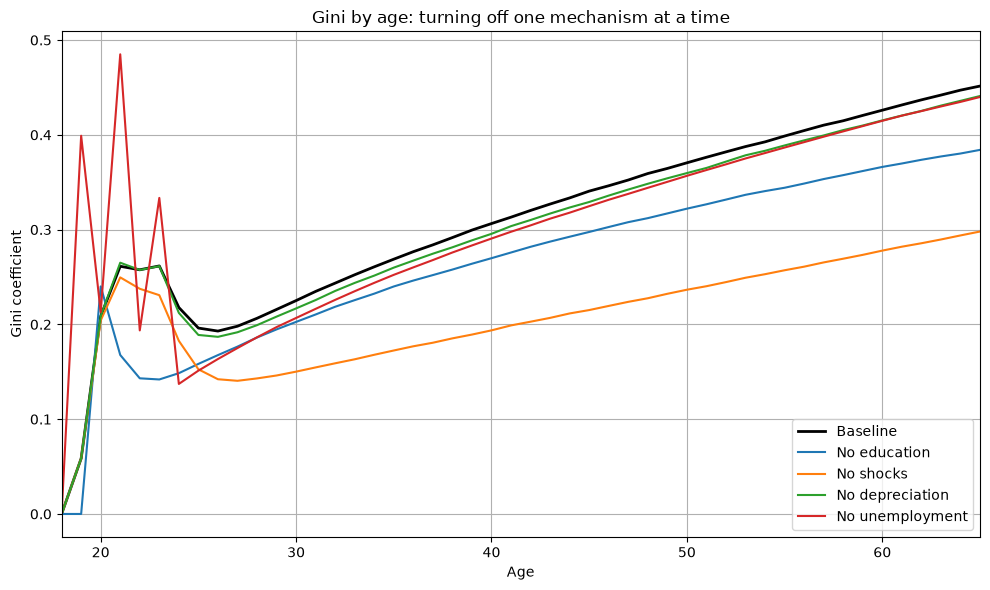

In [35]:
plt.figure(figsize=(10, 6))

for name, inc in scenarios.items():
    if name == 'Baseline':
        plt.plot(ages, gini_by_age(inc), label=name, color='black', linewidth=2)
    else:
        plt.plot(ages, gini_by_age(inc), label=name)

plt.xlabel("Age")
plt.ylabel("Gini coefficient")
plt.title("Gini by age: turning off one mechanism at a time")
plt.legend()
plt.grid(True)
plt.xlim(18, 65)
plt.tight_layout()
plt.show()

Interpretation: Removing human capital shocks lowers the Gini the most, both pooled and within age, so shocks are the strongest driver of inequality in the model. Removing education differences also lowers inequality clearly. Removing depreciation or unemployment raises the Gini slightly, meaning these two mechanisms actually reduce inequality a little in this model. The by-age plot shows that shocks and education matter across the whole life cycle, and that their effect grows with age as differences accumulate.

## 2.5 Extension: health risk

We add health risk as an extra source of uncertainty. The chance of becoming sick is low when young and rises with age, and sick individuals can recover with a probability that falls with age. For employed individuals, being sick cuts income to 70% of normal.

We compare the extension against the baseline, both pooled and by age.

In [36]:
importlib.reload(opgave2)

education_health, ages_health, state_health, human_capital_health, income_health, healthy = opgave2.simulate_health_risk()

# pooled comparison
gini_health = gini(income_health.flatten())
print("Pooled Gini, baseline:   ", round(gini_pooled, 3))
print("Pooled Gini, health risk:", round(gini_health, 3))

Pooled Gini, baseline:    0.377
Pooled Gini, health risk: 0.376


### Gini by age: baseline versus health risk

Plotting the Gini at each age for both models shows where the health risk adds inequality, even if the pooled effect is small.

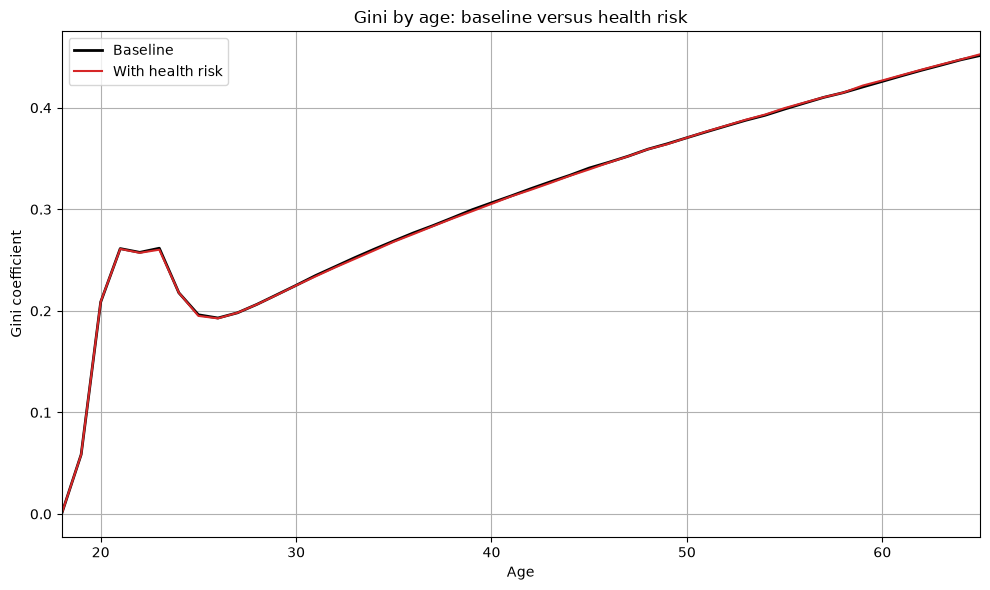

In [37]:
gini_age_health = gini_by_age(income_health)

plt.figure(figsize=(10, 6))
plt.plot(ages, gini_age_baseline, label="Baseline", color='black', linewidth=2)
plt.plot(ages, gini_age_health, label="With health risk", color='tab:red')
plt.xlabel("Age")
plt.ylabel("Gini coefficient")
plt.title("Gini by age: baseline versus health risk")
plt.legend()
plt.grid(True)
plt.xlim(18, 65)
plt.tight_layout()
plt.show()

Interpretation: The pooled Gini is almost unchanged (0.376 with health risk versus 0.377 in the baseline), so health risk has little effect on overall inequality. But the by-age plot shows the effect is concentrated at older ages, where the chance of being sick is higher: the health-risk line rises above the baseline in the later part of the life cycle. So health risk adds within-age inequality among older individuals, even though its effect on the pooled measure is small.